Exercise 1 Final Project 

For my final project, I plan to develop a machine learning model that predicts driver attention and hazard perception using behavioral and visual data. The primary objective is to classify whether a driver is likely to miss a hazard or exhibit unsafe observation patterns based on features such as gaze direction, fixation duration, scan frequency, and reaction time. I will begin by working with an existing dataset related to driver behavior or attention to build and evaluate baseline models, including traditional machine learning approaches and neural networks. Additionally, I am developing a custom driving observation simulator that presents panoramic driving scenarios and tracks user head movement and interactions. If time permits, I will extend my project by incorporating data generated from this simulator to test how well the trained models generalize to a more interactive environment. I am also interested in exploring sequence-based models to capture temporal patterns in driver behavior and analyzing which features most strongly contribute to accurate predictions. This project aims to combine applied machine learning with human behavioral modeling in a context relevant to driver safety and training.

Exercise 2 MNIST Hand-Written Digits Classified using Pytho

In [11]:
import tensorflow as tf
from autograd import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
train_labels.shape=(1,60000)
test_labels.shape=(1,10000)
train_images=(train_images.reshape(60000,784)).T
test_images=(test_images.reshape(10000,784)).T



(1, 60000)


In [12]:
# compute C linear combinations of input point, one per classifier
def model(x,w):
    a = w[0] + np.dot(x.T,w[1:])
    return a.T
    # multiclass perceptron
def multiclass_perceptron(w,x,y,iter):
    # get subset of points
    x_p = x[:,iter]
    y_p = y[:,iter]
    # pre-compute predictions on all points
    all_evals = model(x_p,w)
    # compute maximum across data points
    a = np.max(all_evals,axis = 0)
    # compute cost in compact form using numpy broadcasting
    b = all_evals[y_p.astype(int).flatten(),np.arange(np.size(y_p))]
    cost = np.sum(a - b)
    # return average
    return cost/float(np.size(y_p))

In [13]:
# import automatic differentiator to compute gradient module
from autograd import grad 

# gradient descent function - inputs: g (input function), alpha (steplength parameter), max_its (maximum number of iterations), w (initialization)
def mini_batch_gradient_descent(x,y,alpha,max_its,w, batch_size):
    # compute gradient module using autograd
    weight_history = [w]
    cost_history = []

    train_num = x.shape[1]
    num_batch = int(np.ceil(train_num / batch_size))


    for epoch in range(max_its):

        for batch in range(num_batch) : 

            batch_indx = np.arange(batch * batch_size, min((batch + 1)* batch_size, train_num))

            def g_batch(W) : 
                return multiclass_perceptron(W, x, y, batch_indx)

            grad_eval = grad(g_batch)(w)

            w = w - alpha*grad_eval

            if np.any(np.isnan(w)) :
                print('NAN value found')
                return cost_history, weight_history
    

        full_cost  = multiclass_perceptron(w, x, y, np.arange(train_num))
        cost_history.append(full_cost)
        weight_history.append(w)

        print(f"epoch {epoch}: cost={full_cost}")


    return cost_history, weight_history

epoch 0: cost=16.378965974606437
epoch 1: cost=14.163424502369802
epoch 2: cost=13.882468548638426
epoch 3: cost=11.823566237744213
epoch 4: cost=11.980290219365234
epoch 0: cost=239.997238805542
epoch 1: cost=179.41488638727427
epoch 2: cost=156.61027750497388
epoch 3: cost=122.492109750817
epoch 4: cost=110.19677640907898


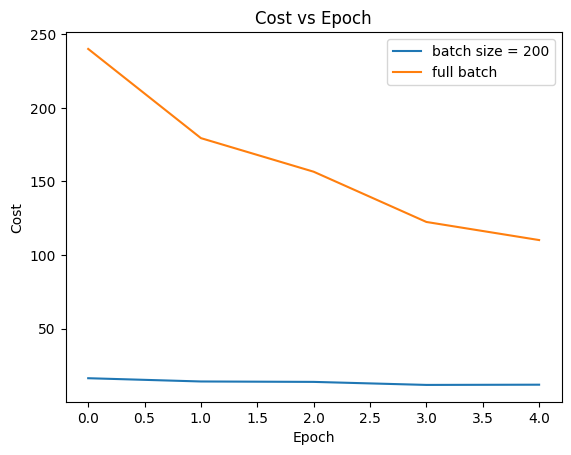

In [20]:

import matplotlib.pyplot as plt
from MLRPlotting import static_plotter
import matplotlib.pyplot as plt

static_plotter = static_plotter.Visualizer()

max_its = 5
alpha = 0.001
N = 784
C = 10 
w1 = 0.1*np.random.randn(N+1,C)
w2 = 0.1*np.random.randn(N+1,C)
batch_size = 200 
x = train_images
y = train_labels
cost_hist_200, weight_history_200  = mini_batch_gradient_descent(x, y, alpha, max_its, w1, batch_size)
cost_hist_full, _ = mini_batch_gradient_descent(x, y, alpha, max_its, w2, x.shape[1])


plt.plot(cost_hist_200, label="batch size = 200")
plt.plot(cost_hist_full, label="full batch")

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.legend()
plt.title("Cost vs Epoch")
plt.show()


Exercise 2.3 


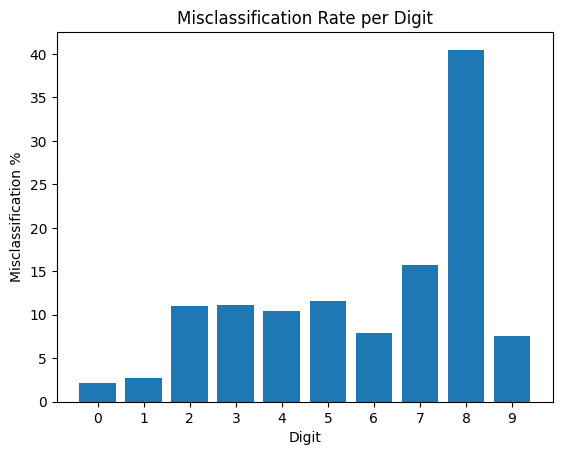

In [22]:
w_best = weight_history_200[-1]

score = model(x, w_best)

pred = np.argmax(score, axis=0)

y_true = y.flatten()

error_rates  = []

for digit in range(10) : 

    indx = np.where(y_true == digit)[0]

    pred_digit = pred[indx]

    true_digit = y_true[indx]

    errors = np.sum(pred_digit != true_digit)


    error_rate = 100 * errors / len(indx)

    error_rates.append(error_rate)


plt.bar(range(10), error_rates)
plt.xlabel("Digit")
plt.ylabel("Misclassification %")
plt.title("Misclassification Rate per Digit")
plt.xticks(range(10))
plt.show()



From this histogram present, the digits 5, 8, and 7 are the most missclassified. most likely due to the compleixity as well as their similarity to other digits. for isntance, 8 can look a lot like 0 or 9 in some cases 

Exercise 4 PCA

In [31]:


def center(X):
    X_means = np.mean(X,axis=1)[:,np.newaxis]
    X_normalized = X - X_means

    return X_normalized

def compute_pcs(X,lam):
    # create the correlation matrix
    P = float(X.shape[1])
    Cov = 1/P*np.dot(X,X.T) + lam*np.eye(X.shape[0])

    # use numpy function to compute eigenvalues / vectors of correlation matrix
    D,V = np.linalg.eigh(Cov)
    return D,V

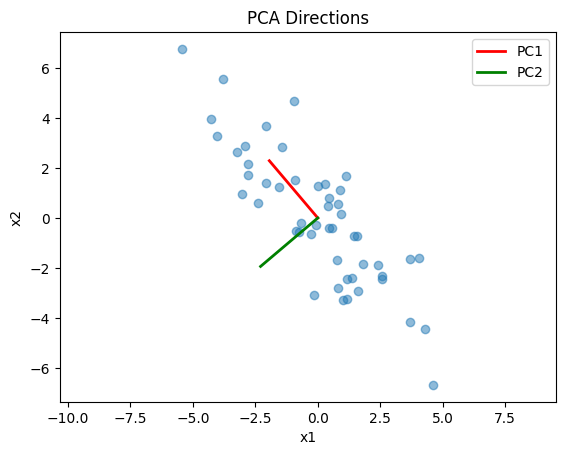

In [32]:
csvname = '2d_span_data.csv'
X_original = np.loadtxt(csvname, delimiter = ',')

X = center(X_original)

lam = 1e-5
D, V = compute_pcs(X, lam)

idx = np.argsort(D)[::-1]
D = D[idx]
V = V[:, idx]

plt.figure()

plt.scatter(X[0,:], X[1,:], alpha=0.5)

origin = np.array([[0],[0]])

scale = 3

plt.plot([0, scale*V[0,0]], [0, scale*V[1,0]], 'r-', linewidth=2, label='PC1')

plt.plot([0, scale*V[0,1]], [0, scale*V[1,1]], 'g-', linewidth=2, label='PC2')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("PCA Directions")
plt.legend()
plt.axis('equal')
plt.show()

Exercise 5 K-Means Clustering

In [33]:
data = np.loadtxt('blobs (1).dat')


def update_assignments(data,centroids):

    N = data.shape[1]
    K = centroids.shape[1]

    assignments = np.zeros(N, dtype=int)

    for i in range(N) : 
        distances = np.sum((centroids - data[:, i:i+1])**2, axis=0)
        assignments[i] = np.argmin(distances)

    return assignments


def update_centroids(data,old_centroids,assignments):


    K = old_centroids.shape[1]
    D = data.shape[0]

    new_centroids = np.zeros((D, K))

    for k in range(K) : 

        points = data[:, assignments == k] 

        if points.shape[1] > 0: 
            new_centroids[:, k] = np.mean(points, axis=1)
        else : 
            new_centroids[:, k] = old_centroids[:, k]
    

    return new_centroids

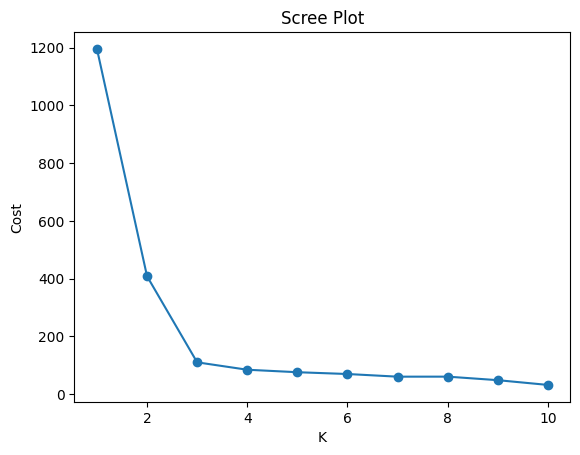

In [36]:
indcs = np.random.choice(data.shape[1], 3, replace=False)
centroids = data[:, indcs]

for i in range(5) : 
    assignments = update_assignments(data, centroids)
    centroids = update_centroids(data, centroids, assignments)


def compute_cost(data, centroids, assignments) : 
    cost = 0
    for i in range(data.shape[1]) : 
        c = assignments[i]
        cost += np.sum((data[:, i] - centroids[:, c])**2)
    
    return cost 



costs = []

for K in range(1, 11) : 
    indices = np.random.choice(data.shape[1], K, replace=False)
    centroids = data[:, indices]

    for _ in range(5) : 
        assignments = update_assignments(data, centroids)
        centroids = update_centroids(data, centroids, assignments)

    
    cost = compute_cost(data, centroids, assignments)
    costs.append(cost)

plt.plot(range(1,11), costs, marker='o')
plt.xlabel("K")
plt.ylabel("Cost")
plt.title("Scree Plot")
plt.show()



Exercise 6 Fraud Detection

(1372, 5)
(1372, 2)
(1372,)


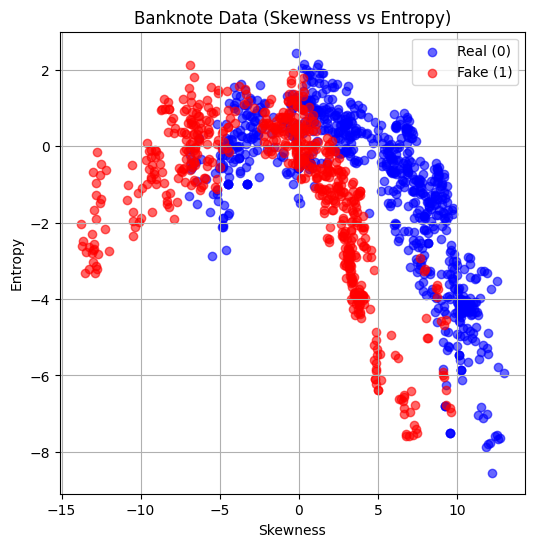

In [38]:
import numpy as np
from urllib.request import urlopen
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt' 
raw_data = urlopen(url)
dataset = np.loadtxt(raw_data, delimiter=",")
print(dataset.shape)

X=dataset[:,[1,3]]
Y=dataset[:,4]
print(X.shape)
print(Y.shape)

fake = X[Y == 1]
real = X[Y == 0]


plt.figure(figsize=(6,6))

plt.scatter(real[:,0], real[:,1], color='blue', label='Real (0)', alpha=0.6)
plt.scatter(fake[:,0], fake[:,1], color='red', label='Fake (1)', alpha=0.6)

plt.xlabel("Skewness")
plt.ylabel("Entropy")
plt.title("Banknote Data (Skewness vs Entropy)")
plt.legend()
plt.grid(True)

plt.show()

Exercise 6.2

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(1, batch_input_shape=(None, 2), activation='sigmoid')
])

Epoch 1/400
11/11 [==============================] - 0s 1ms/step - loss: 0.6277 - accuracy: 0.7004
Epoch 2/400
11/11 [==============================] - 0s 872us/step - loss: 0.5169 - accuracy: 0.7340
Epoch 3/400
11/11 [==============================] - 0s 768us/step - loss: 0.5143 - accuracy: 0.7318
Epoch 4/400
11/11 [==============================] - 0s 803us/step - loss: 0.5172 - accuracy: 0.7223
Epoch 5/400
11/11 [==============================] - 0s 759us/step - loss: 0.5165 - accuracy: 0.7208
Epoch 6/400
11/11 [==============================] - 0s 892us/step - loss: 0.5144 - accuracy: 0.7194
Epoch 7/400
11/11 [==============================] - 0s 666us/step - loss: 0.5134 - accuracy: 0.7150
Epoch 8/400
11/11 [==============================] - 0s 1ms/step - loss: 0.5144 - accuracy: 0.7106
Epoch 9/400
11/11 [==============================] - 0s 997us/step - loss: 0.5136 - accuracy: 0.7143
Epoch 10/400
11/11 [==============================] - 0s 817us/step - loss: 0.5129 - accuracy: 

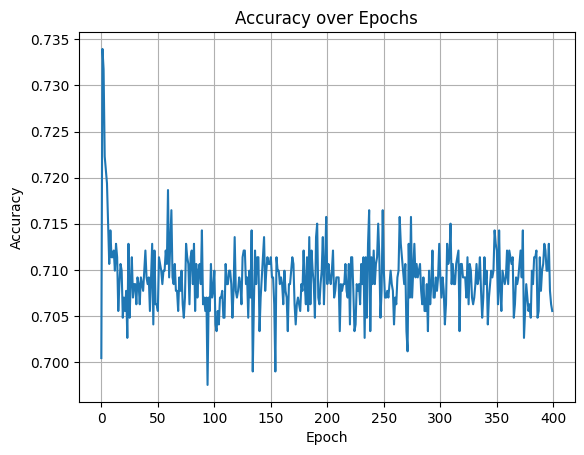

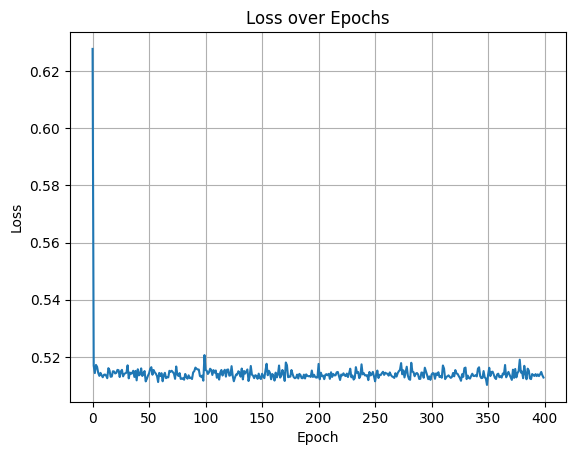

In [42]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.15),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X, Y,
    epochs=400,
    batch_size=128,
    verbose=1
)

plt.plot(history.history['accuracy'])
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.plot(history.history['loss'])
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

79/79 [==============================] - 0s 477us/step


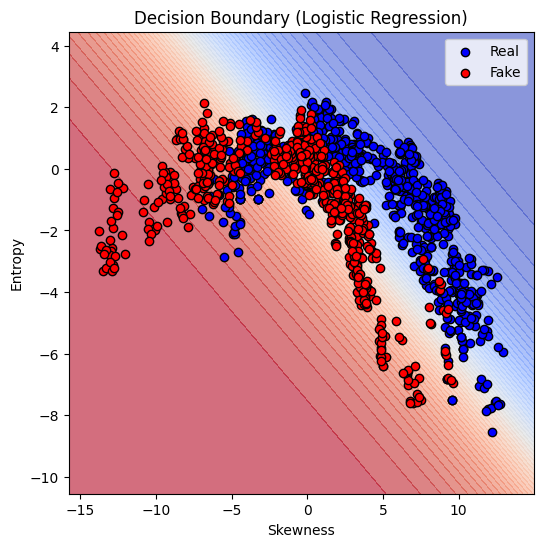

In [43]:
x1list = np.linspace(np.min(X[:,0])-2, np.max(X[:,0])+2, 50) # Define 50 points on the x1-axis
x2list = np.linspace(np.min(X[:,1])-2, np.max(X[:,1])+2, 50) # Define 50 points on the x2-axis

X1, X2 = np.meshgrid(x1list, x2list)
grid_points = np.c_[X1.ravel(), X2.ravel()]
preds = model.predict(grid_points)
Z = preds.reshape(X1.shape)

plt.figure(figsize=(6,6))

plt.contourf(X1, X2, Z, levels=50, cmap='coolwarm', alpha=0.6)
fake = X[Y == 1]
real = X[Y == 0]

plt.scatter(real[:,0], real[:,1], color='blue', label='Real', edgecolors='k')
plt.scatter(fake[:,0], fake[:,1], color='red', label='Fake', edgecolors='k')

plt.xlabel("Skewness")
plt.ylabel("Entropy")
plt.title("Decision Boundary (Logistic Regression)")
plt.legend()
plt.show()

In the contour plot it shows a linear decision boundary separating the two classes. This confirms that logistic regression learns linear separation in the input space. although the model does preform well, there is some overlap between the classes, indicative of the models incapability to perfectly separate the data. 

In [45]:
from tensorflow.keras.utils import to_categorical 
Y_c=to_categorical(Y,2)

model = Sequential([
    Dense(8, activation='sigmoid', input_shape=(2,)),   
    Dense(2, activation='softmax')                      
])



Epoch 1/400
11/11 [==============================] - 0s 865us/step - loss: 0.5905 - accuracy: 0.6268
Epoch 2/400
11/11 [==============================] - 0s 653us/step - loss: 0.5585 - accuracy: 0.6647
Epoch 3/400
11/11 [==============================] - 0s 851us/step - loss: 0.5482 - accuracy: 0.6866
Epoch 4/400
11/11 [==============================] - 0s 805us/step - loss: 0.5395 - accuracy: 0.7128
Epoch 5/400
11/11 [==============================] - 0s 775us/step - loss: 0.5319 - accuracy: 0.7201
Epoch 6/400
11/11 [==============================] - 0s 798us/step - loss: 0.5248 - accuracy: 0.7077
Epoch 7/400
11/11 [==============================] - 0s 804us/step - loss: 0.5197 - accuracy: 0.7325
Epoch 8/400
11/11 [==============================] - 0s 735us/step - loss: 0.5140 - accuracy: 0.7245
Epoch 9/400
11/11 [==============================] - 0s 664us/step - loss: 0.5099 - accuracy: 0.7259
Epoch 10/400
11/11 [==============================] - 0s 880us/step - loss: 0.5059 - accura

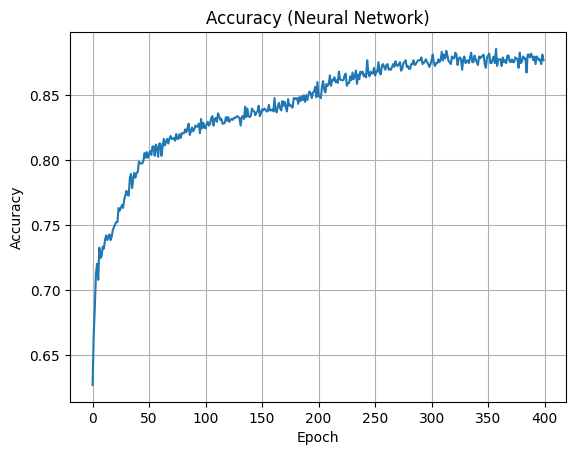

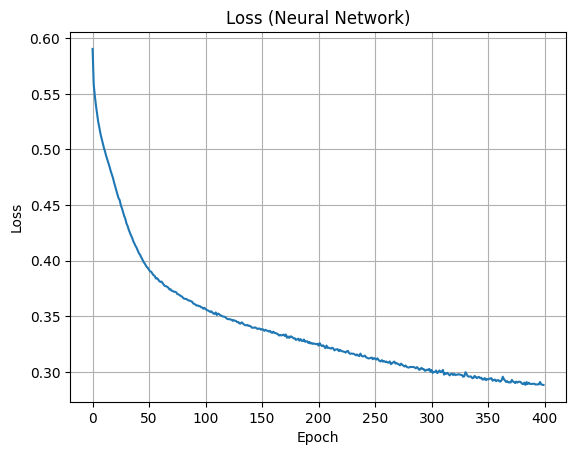

In [46]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.15),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X, Y_c,
    epochs=400,
    batch_size=128,
    verbose=1
)


plt.plot(history.history['accuracy'])
plt.title("Accuracy (Neural Network)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.plot(history.history['loss'])
plt.title("Loss (Neural Network)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

The neural network achieved an improvement in preformance compared to logistic regression. as a result of the hidden layer, the model is able to learn nonlinear decision boundaries, allwoing it a better job at separating the overallping regions of data. resulting in higher accuracy, and lower loss, the main advantage of using such a model. 

79/79 [==============================] - 0s 530us/step


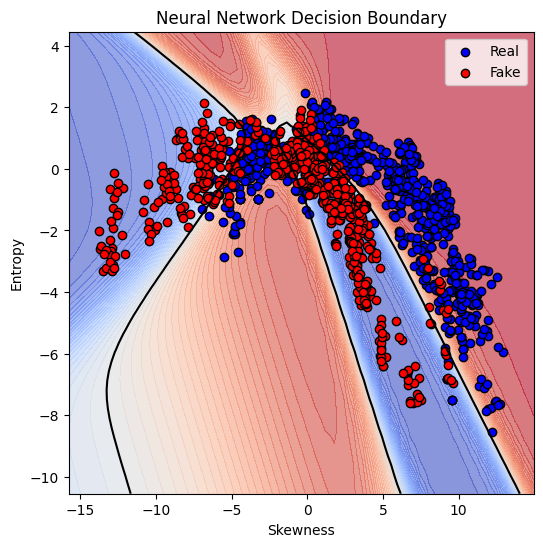

In [48]:
x1list = np.linspace(np.min(X[:,0])-2, np.max(X[:,0])+2, 50) # Define 50 points on the x1-axis
x2list = np.linspace(np.min(X[:,1])-2, np.max(X[:,1])+2, 50) # Define 50 points on the x2-axis

X1, X2 = np.meshgrid(x1list, x2list)
grid_points = np.c_[X1.ravel(), X2.ravel()]
preds = model.predict(grid_points)
Z = preds[:, 0]
Z = Z.reshape(X1.shape)

plt.figure(figsize=(6,6))


plt.contourf(X1, X2, Z, levels=50, cmap='coolwarm', alpha=0.6)

plt.contour(X1, X2, Z, levels=[0.5], colors='black')

fake = X[Y == 1]
real = X[Y == 0]

plt.scatter(real[:,0], real[:,1], color='blue', label='Real', edgecolors='k')
plt.scatter(fake[:,0], fake[:,1], color='red', label='Fake', edgecolors='k')

plt.xlabel("Skewness")
plt.ylabel("Entropy")
plt.title("Neural Network Decision Boundary")
plt.legend()

plt.show()

compared to logisitc regressionm the neural network produces a nonlinear decision boundary, which better caputres the nature of the data. this allows the model to more effectively separate overlapping regions between the fake and real banknotes. as a resulm,t an improved classification preformance over the linear model. 